In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from influxdb_client import InfluxDBClient
import os
from dotenv import load_dotenv


In [2]:

load_dotenv()

INFLUX_URL = os.getenv("INFLUX_URL", "http://localhost:8086")
INFLUX_TOKEN = os.getenv("INFLUX_TOKEN")
INFLUX_ORG = os.getenv("INFLUX_ORG", "casa")
INFLUX_BUCKET = os.getenv("INFLUX_BUCKET", "monitoraggio_pi")


if not INFLUX_TOKEN:
    print("Errore: INFLUX_TOKEN non trovato! WTF .env.")
else:
    print(f" Configurazione caricata correttamente!")
    print(f" URL: {INFLUX_URL} |  Bucket: {INFLUX_BUCKET}")
    
# Inizializza il client
client = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG)
query_api = client.query_api()

query = f'''
from(bucket: "{INFLUX_BUCKET}")
  |> range(start: -3h)
  |> filter(fn: (r) => r["_measurement"] == "ambiente")
'''

df = query_api.query_data_frame(query)
client.close()

df.head()


 Configurazione caricata correttamente!
 URL: http://10.26.169.209:8086 |  Bucket: monitoraggio_pi


/home/linkyolo/anaconda3/lib/python3.13/site-packages/influxdb_client/client/warnings.py:31: MissingPivotFunction: The query doesn't contains the pivot() function.

The result will not be shaped to optimal processing by pandas.DataFrame. Use the pivot() function by:

    
from(bucket: "monitoraggio_pi")
  |> range(start: -3h)
  |> filter(fn: (r) => r["_measurement"] == "ambiente")
 |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")

You can disable this warning by:
    import warnings
    from influxdb_client.client.warnings import MissingPivotFunction

    warnings.simplefilter("ignore", MissingPivotFunction)

For more info see:
    - https://docs.influxdata.com/resources/videos/pivots-in-flux/
    - https://docs.influxdata.com/flux/latest/stdlib/universe/pivot/
    - https://docs.influxdata.com/flux/latest/stdlib/influxdata/influxdb/schema/fieldsascols/

  warnings.warn(message, MissingPivotFunction)


,result,table,_start,_stop,_time,_value,_field,_measurement,host,stanza
0,_result,0,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 08:19:14.559159+00:00,34.8,percepita,ambiente,raspberry_pi_4,camera
1,_result,0,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 08:19:19.864254+00:00,34.8,percepita,ambiente,raspberry_pi_4,camera
2,_result,0,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 08:19:25.154050+00:00,34.8,percepita,ambiente,raspberry_pi_4,camera
3,_result,0,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 08:19:35.711332+00:00,34.6,percepita,ambiente,raspberry_pi_4,camera
4,_result,0,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 08:19:40.980813+00:00,34.6,percepita,ambiente,raspberry_pi_4,camera


In [3]:
df.to_csv("data/days/18-luglio-2026.csv")

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from influxdb_client import InfluxDBClient
import os
from dotenv import load_dotenv
from influxdb_client import InfluxDBClient
df = pd.read_csv( "data/days/18-luglio-2026.csv")

In [5]:
df.tail()

,Unnamed: 0,result,table,_start,_stop,_time,_value,_field,_measurement,host,stanza
1639,1639,_result,2,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 09:09:07.806178+00:00,43.0,umidita,ambiente,raspberry_pi_4,camera
1640,1640,_result,2,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 09:09:13.076129+00:00,43.0,umidita,ambiente,raspberry_pi_4,camera
1641,1641,_result,2,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 09:09:18.336261+00:00,43.0,umidita,ambiente,raspberry_pi_4,camera
1642,1642,_result,2,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 09:09:23.605544+00:00,43.0,umidita,ambiente,raspberry_pi_4,camera
1643,1643,_result,2,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 09:09:28.865798+00:00,43.0,umidita,ambiente,raspberry_pi_4,camera


In [10]:
class Evento:
    def __init__(self, description, time, color='b'):

        self.description = description
        self.time = time
        self.color = color 

allEvents = [
    
    Evento('corr verso stanza', pd.to_datetime("2026-07-18 08:40:28.865798+00:00"), 'g'),

] 

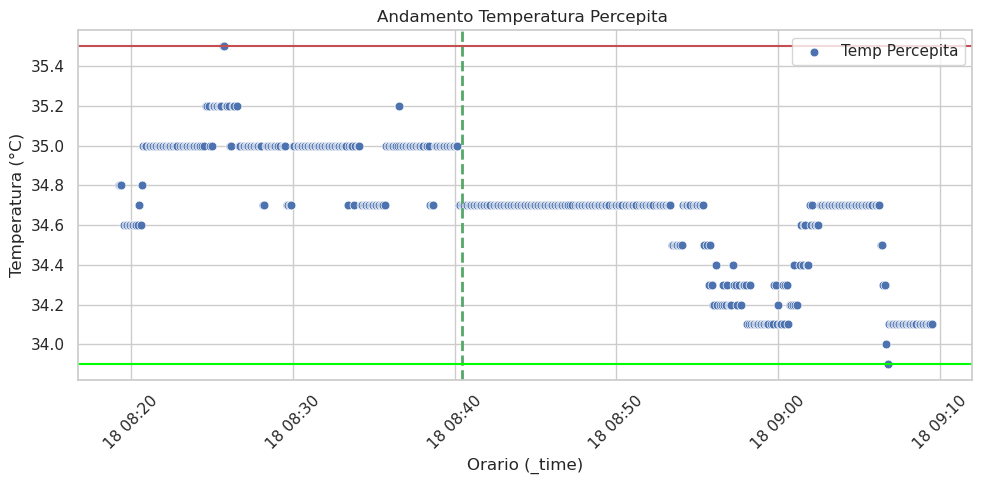

In [12]:
import seaborn as sns

df_loaded = df
df_loaded['_time'] = pd.to_datetime(df_loaded['_time'])
df_target = df_loaded[df_loaded['_field'] == 'percepita'].copy()

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.scatterplot(data=df_target, x='_time', y='_value',  color='b', s=40, label='Temp Percepita')

for event in allEvents:
    plt.axvline(x=event.time, color=event.color, linestyle='--', linewidth=2, label=event.description)

#minimo
plt.axhline(df_target['_value'].min(), color='lime')
plt.axhline(df_target['_value'].max(), color='r')
plt.title('Andamento Temperatura Percepita ')
plt.xlabel('Orario (_time)')
plt.ylabel('Temperatura (°C)')
plt.xticks(rotation=45)
#plt.legend()
plt.tight_layout()

plt.show()
#plt.savefig('temp_plot.png')

plt.close()


In [13]:
df.head()

,Unnamed: 0,result,table,_start,_stop,_time,_value,_field,_measurement,host,stanza
0,0,_result,0,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 08:19:14.559159+00:00,34.8,percepita,ambiente,raspberry_pi_4,camera
1,1,_result,0,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 08:19:19.864254+00:00,34.8,percepita,ambiente,raspberry_pi_4,camera
2,2,_result,0,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 08:19:25.154050+00:00,34.8,percepita,ambiente,raspberry_pi_4,camera
3,3,_result,0,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 08:19:35.711332+00:00,34.6,percepita,ambiente,raspberry_pi_4,camera
4,4,_result,0,2026-07-18 06:09:33.442244+00:00,2026-07-18 09:09:33.442244+00:00,2026-07-18 08:19:40.980813+00:00,34.6,percepita,ambiente,raspberry_pi_4,camera


In [16]:
def load_and_clean_data(file_path):
    df = pd.read_csv(file_path, parse_dates=['_time'])
    
    # 2. Pivot Table: trasformiamo le righe di _field in colonne
    # aggfunc='mean' gestisce il caso in cui hai più misurazioni nello stesso istante
    df_pivot = df.pivot_table(
        index='_time', 
        columns='_field', 
        values='_value', 
        aggfunc='mean'
    )
    
    # 3. Resample: per serie temporali disomogenee
    # Uniformiamo tutto su base minuto.
    return df_pivot.resample('min').mean().interpolate(method='linear')

df_clean = load_and_clean_data( "data/days/18-luglio-2026.csv")
df_clean

_field,percepita,temperatura,umidita
_time,,,
2026-07-18 08:19:00+00:00,34.675000,32.800000,45.375000
2026-07-18 08:20:00+00:00,34.736364,33.018182,44.000000
2026-07-18 08:21:00+00:00,35.000000,33.300000,43.000000
2026-07-18 08:22:00+00:00,35.000000,33.300000,43.000000
2026-07-18 08:23:00+00:00,35.000000,33.300000,43.000000
2026-07-18 08:24:00+00:00,35.054545,33.300000,43.272727
2026-07-18 08:25:00+00:00,35.254545,33.300000,44.181818
2026-07-18 08:26:00+00:00,35.088889,33.300000,43.444444
2026-07-18 08:27:00+00:00,35.000000,33.300000,43.000000


<Axes: xlabel='_time'>

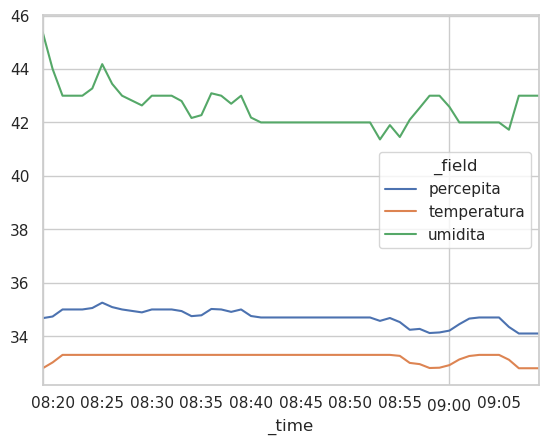

In [17]:
df_clean.plot()

<Axes: xlabel='Giorno', ylabel='Ora'>

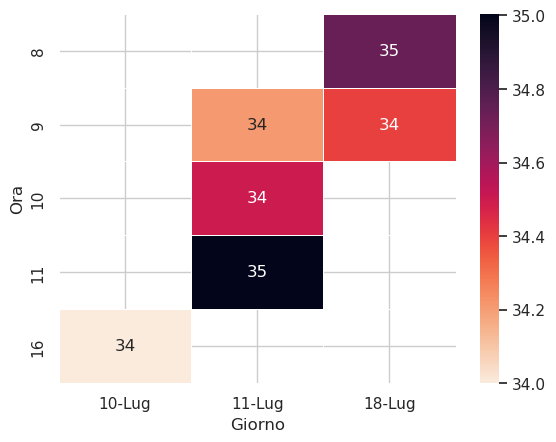

In [37]:

df_10_luglio= load_and_clean_data( "data/days/10-luglio-2026.csv")
df_11_luglio= load_and_clean_data( "data/days/11-luglio-2026.csv")
df_18_luglio= load_and_clean_data( "data/days/18-luglio-2026.csv")

df_list = [df_10_luglio, df_11_luglio, df_18_luglio]
all_data = pd.concat(df_list, keys=['10-Lug', '11-Lug', '18-Lug'])
all_data = all_data.reset_index(level=0).rename(columns={'level_0': 'Giorno'})

# Creiamo le feature di tempo
all_data['Ora'] = all_data.index.hour

# Pivot per la Heatmap
heatmap_matrix = all_data.pivot_table(
    index='Ora', 
    columns='Giorno', 
    values='percepita', 
    aggfunc='median'
)
sns.heatmap(heatmap_matrix, cmap='rocket_r', annot= True, linewidths=0.5)

In [33]:
all_data[all_data['Giorno'] == '11-Lug'].tail(5)

_field,Giorno,percepita,temperatura,umidita,Ora
_time,,,,,
2026-07-11 11:17:00+00:00,11-Lug,34.900000,33.681818,40.0,11
2026-07-11 11:18:00+00:00,11-Lug,34.883333,33.671212,40.0,11
2026-07-11 11:19:00+00:00,11-Lug,34.866667,33.660606,40.0,11
2026-07-11 11:20:00+00:00,11-Lug,34.850000,33.650000,40.0,11
2026-07-11 11:21:00+00:00,11-Lug,35.100000,33.800000,40.0,11


<Axes: xlabel='Ora', ylabel='percepita'>

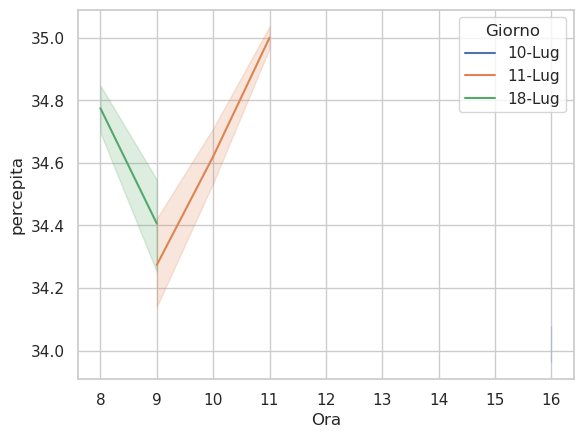

In [54]:
sns.lineplot(all_data, x='Ora', y='percepita', hue='Giorno')

<Axes: xlabel='Ora', ylabel='percepita'>

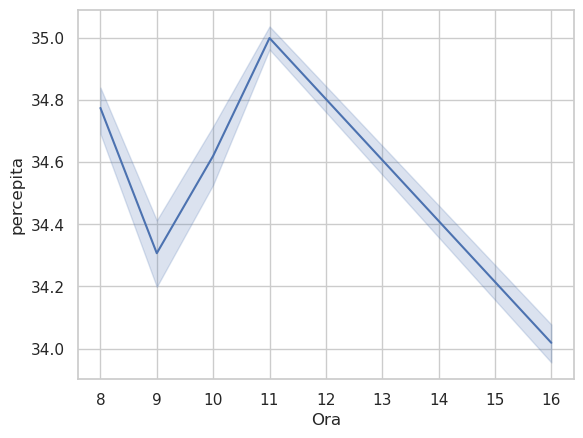

In [56]:
#df_11 = all_data[all_data['Giorno'] == '18-Lug']
sns.lineplot(all_data,  y='percepita', x="Ora")

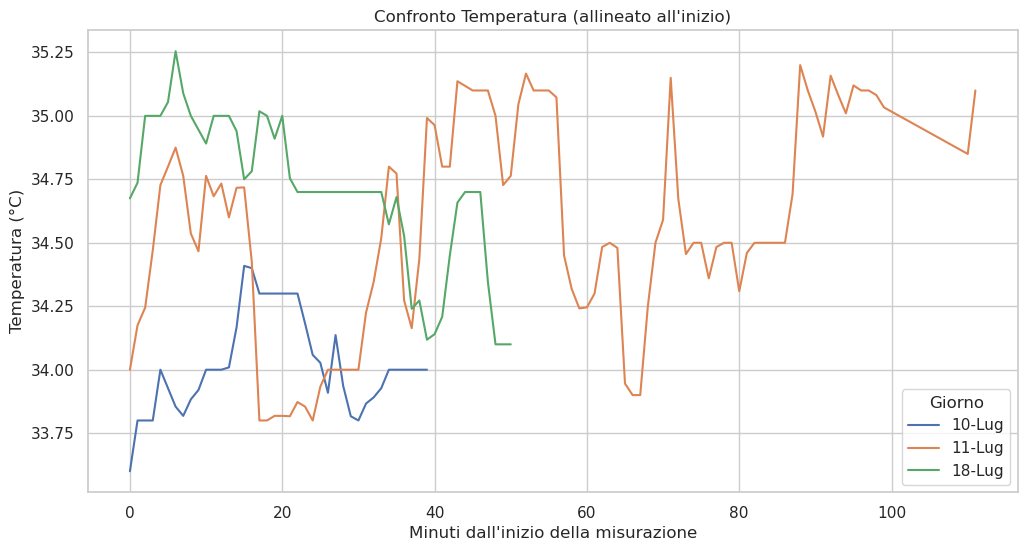

In [53]:
df_plot = all_data.copy()
df_plot = df_plot.reset_index() 
start_times = df_plot.groupby('Giorno')['_time'].transform('min')

df_plot['TimeRelative'] = df_plot['_time'] - start_times
df_plot['MinutesRelative'] = df_plot['TimeRelative'].dt.total_seconds() / 60

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_plot, 
    x='MinutesRelative', 
    y='percepita', 
    hue='Giorno'
)
plt.title('Confronto Temperatura (allineato all\'inizio)')
plt.xlabel('Minuti dall\'inizio della misurazione')
plt.ylabel('Temperatura (°C)')
plt.show()

In [22]:
#Test per la prossima volta volta che accendo il pi
from utils import fetch_influx_data

query = f'''
from(bucket: "{INFLUX_BUCKET}")
  |> range(start: -3h)
  |> filter(fn: (r) => r["_measurement"] == "ambiente")
  |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")
'''

test = fetch_influx_data(query, INFLUX_URL, INFLUX_TOKEN, INFLUX_ORG)
test

NewConnectionError: <urllib3.connection.HTTPConnection object at 0x7f5c3bfbfd90>: Failed to establish a new connection: [Errno 113] No route to host